# MA124 Maths by Computer: Assignment 2

---


Student number: 2012113

## A. The SIR model with birth and death 

A simple SIR model including birth and death is given by the following system of ODEs

$$
\dot S  = \mu N - \frac{\beta S I}{N} - \mu S, \quad 
\dot I  = \frac{\beta S I}{N} - \gamma I - \mu I, \quad 
\dot R  = \gamma I - \mu R,
$$

where $S$ is the number of susceptible individuals, $I$ is the number of infectious individuals, $R$ is the number of recovered or removed individuals. $N$ is the total number of individuals, i.e. $N = S+I+R$. One can easily verify that $\dot N = 0$ by adding the three equation. Hence $N$ is constant. $\beta$, $\gamma$ and $\mu$ are parameters: $\beta$ is the average number of contacts per person per time, $\gamma$ is the reciprocal of the time an individual remains infectious, 
$\mu$ is both the birth rate and death rate -- these rates are taken to be the same in this model. All newborns enter the susceptible category at rate $\mu N$, while deaths occur uniformly for each category. Whether or not this model is realistic, we can examine its solutions with numerical simulations. (You can find a readable treatment of this model [here](https://peerj.com/articles/pchem-14/).)

This model is based on the hypotheses: homogenous population, the whole population is susceptible, recovered patients are not longer infectious and infectivity rate is constant. We are going to use this model to study the COVID-19 outbreak in Spain.  Spain has a total population of $N=47,000,000$. Spain registered the first positive the 31st January 2020. It is estimated that by February 21 there were 14 infected which we will use as our initial value: $S(0)=46,999,986$,$I(0)=14$ and $R(0)=0$. 

The basic reproduction ratio is given by $R_0 = \frac{\beta}{\gamma + \mu}$.The parameters $\beta$ and $\gamma$ are estimated to be $\beta = 0.42$, $\gamma = 0.166$( data taken from [here](https://www.sciencedirect.com/science/article/pii/S2468042720300403)) and $\mu = 0.00762$ (for year 2019 [here](https://www.ine.es/jaxiT3/Datos.htm?t=1433#!tabs-tabla)), which correspond to $R_0 = 2.42$

The code below plots the time series of S,I,R and the phase portrait in the (S,I) plane.

When we introduce the parameter $\mu$ birth rate/death rate, we observe that there are more than one infection "peaks", whereas when $\mu = 0$ there was only one.

In the phase portrait, a diamond shows the initial point, a star the maximum infected and a circle the final point of the trajectory.


In [1]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

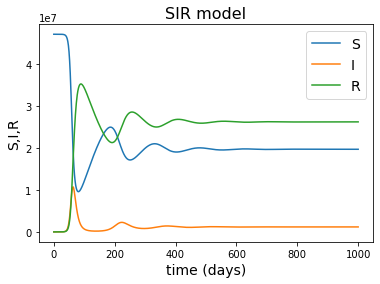

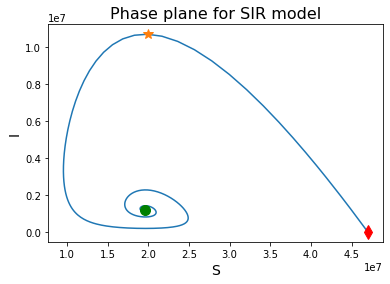

The maximum of I is I(t=63) = 10704608
At the end of the simulation, the final value of S, I, and R are (as integer values):
S(t=tf) = 19649814
I(t=tf) = 1186875
R(t=tf) = 26163311


In [2]:
# --- First define the RHS of ODE system --- #


def SIR(y, t):
    # returns RHS of the SIR model
    S, I, R = y

    beta = 0.42
    gamma = 0.168
    mu = 0.00762
    
    N = S + I + R
    Sdot = mu*N -beta * S * I / N - mu*S 
    Idot = beta * S * I / N - gamma * I - mu*I
    Rdot = gamma * I - mu*R
    
    return Sdot, Idot, Rdot

# --- Problem setup --- #

# Set initial conditions and put into array y0
S0 = 46999986
I0 = 14
R0 = 0
y0 = np.array([S0, I0, R0])

# set up time grid for solution
tf = 1000
Nsteps = 1000
t= np.linspace(0, tf, Nsteps+1)

# --- Call the ODE solver and extract solutions --- #
  
y_sol = odeint(SIR, y0, t)

# extract S, I, R from the solution array y
S = y_sol[:,0]
I = y_sol[:,1]
R = y_sol[:,2]


# calculates maximum of I
for i in range(0,Nsteps+1):
    if I[i] == np.max(I):
        k = i

# --- Plot various interesting things --- #

# plot the time evolution of the S, I, R
plt.plot(t, S, label="S")
plt.plot(t, I, label="I")
plt.plot(t, R, label="R")

# labels etc
plt.xlabel("time (days)", fontsize=14)
plt.ylabel("S,I,R", fontsize=14)
plt.title("SIR model", fontsize=16)
plt.legend(fontsize=14)
plt.show()        


# plot the evolution in the S,I phase plane
plt.plot(S, I)

# labels etc
plt.xlabel("S", fontsize=14)
plt.ylabel("I", fontsize=14)
plt.title("Phase plane for SIR model", fontsize=16)

# put some markers to show initial, final and maximum states
plt.plot(S[0], I[0], 'rd', markersize = 10)
plt.plot(S[-1], I[-1], 'go', markersize = 10)
plt.plot(S[k], I[k],'*', markersize = 10)
plt.show()

# --- Report the final values of S, I, R and maximum of I --- #
print("The maximum of I is I(t="+str(k)+") = "+str(round(np.max(I))))
print("At the end of the simulation, the final value of S, I, and R are (as integer values):")
print("S(t=tf) =", round(S[-1]))
print("I(t=tf) =", round(I[-1]))
print("R(t=tf) =", round(R[-1]))


With this model the incident peak would be around April 24, whereas in reality was on March 26. However, we need to have into account that Spain started the first lockdown March 15 which reduced the contagions. We can find the real cases on 26 March ([here](https://ourworldindata.org/coronavirus/country/spain?country=~ESP)) and compare them with March 26 in this model. We can also check how many cases would the model estimate by now.

In [3]:
# t=34 is for 26 March
print("In Spain there were 57886 cumulative cases on 26 March and this model estimates "+ str(round(I[34]))+" infected and "+str(round(R[34])) + " recovered, which makes a total of: " +str(round(I[34]+R[34])))

#t=350 is around 6 Feb 2021 
print("In Spain there were 2.94M cumulative cases and this model estimates "+str(round(I[350]))+" infected and "+str(round(R[350])) + " recovered, which makes a total of: " +str(round(I[350]+R[350])))

In Spain there were 57886 cumulative cases on 26 March and this model estimates 56643 infected and 37819 recovered, which makes a total of: 94462
In Spain there were 2.94M cumulative cases and this model estimates 1289079 infected and 25109483 recovered, which makes a total of: 26398563


As we can see, the model is not realistic for COVID-19 because it does not take into account many other factors. Nevertheless, we can still gather information from it. 